# 🌳 SCA Prototype — Stage: XGBoost Dependency Risk Scoring Model
**MTech Project | Chapter 5.2 — Dependency Risk Scoring Model (SCA)**

```
sca_dataset.csv  (from 05_nvd_data_collection.ipynb)
        ↓
  Preprocessing (impute, normalise, one-hot)
        ↓
  XGBoost Multi-class Classifier   ← YOU ARE HERE
        ↓
  Critical / High / Medium / Low  +  SHAP explanations
```

Trains the SCA risk-scoring model described in Chapter 5.2: an XGBoost multi-class
classifier predicting CVSS severity category, tuned via 5-fold stratified grid search
over the exact hyperparameter grid stated in the dissertation, with SHAP explanations
feeding the recommendation engine (Chapter 5.3).

Run `05_nvd_data_collection.ipynb` first to produce `sca_dataset.csv`.

## 🛠️ 0. Environment Check

`xgboost` and `shap` aren't part of the base scikit-learn stack — if this is a fresh
kernel/environment (e.g. a new conda env, a different machine, or a fresh Colab
runtime), they likely aren't installed yet. This cell installs them if missing so the
rest of the notebook doesn't crash with a `ModuleNotFoundError`.

In [3]:
import os

os.environ["REQUESTS_CA_BUNDLE"] = r"C:\Users\Tejal\miniconda3\Library\ssl\cacert.pem"

In [4]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = ["xgboost", "shap"]


def pip_install(pkg: str):
    """Run pip install and surface the real error output on failure instead of
    swallowing it — 'CalledProcessError' with no output is unhelpful for debugging."""
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", pkg],
        capture_output=True, text=True,
    )
    if result.returncode != 0:
        print(f"❌ pip failed to install '{pkg}'. Full pip output below:\n")
        print(result.stdout[-2000:])
        print(result.stderr[-2000:])
        print(
            f"\nCommon fixes on Windows/conda:\n"
            f"  1) Upgrade pip first:  python -m pip install --upgrade pip\n"
            f"  2) If you're behind a proxy/VPN, pip needs it configured (or try a different network)\n"
            f"  3) Try the %pip magic in a notebook cell (do NOT use %conda — it has a known bug\n"
            f"     on Windows paths, it mis-parses backslashes in conda-meta\\history as regex escapes):\n"
            f"       %pip install {pkg}\n"
            f"  4) Or open a plain Anaconda Prompt (Start menu, not a notebook cell) and run:\n"
            f"       conda install -c conda-forge {pkg}\n"
            f"     then restart this notebook's kernel so it picks up the new package."
        )
        raise RuntimeError(f"Failed to install '{pkg}' — see pip output above for the real cause.")
    print(f"✅ '{pkg}' installed successfully")


for pkg in REQUIRED_PACKAGES:
    if importlib.util.find_spec(pkg) is None:
        print(f"📦 '{pkg}' not found — installing...")
        pip_install(pkg)
    else:
        print(f"✅ '{pkg}' already installed")

📦 'xgboost' not found — installing...
✅ 'xgboost' installed successfully
📦 'shap' not found — installing...
✅ 'shap' installed successfully


## 📦 1. Imports

In [5]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, f1_score)
from xgboost import XGBClassifier

RANDOM_STATE = 42
print("✅ Imports done.")

✅ Imports done.


## 📂 2. Load Dataset

In [6]:
DATA_PATH = "sca_dataset.csv"
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"'{DATA_PATH}' not found. Run 05_nvd_data_collection.ipynb first."
    )

df = pd.read_csv(DATA_PATH)
print(f"Total records : {len(df):,}")
print(df["severity_label"].value_counts())
df.head()

Total records : 14,279
severity_label
MEDIUM      8559
HIGH        3927
CRITICAL    1283
LOW          504
NONE           6
Name: count, dtype: int64


,cve_id,package_guess,cwe_id,cvss_base_score,cvss_exploitability,vuln_count_12m,days_since_patch,patch_lag_days,has_exploit,dependency_depth,maintainer_activity,severity_label
0,CVE-2013-1629,pip,CWE-20,6.8,8.6,1.0,4740.0,4740.0,1,10.0,1.17,MEDIUM
1,CVE-2013-1630,pyshop,CWE-20,6.8,8.6,1.0,1423.0,1423.0,0,1.0,0.00,MEDIUM
2,CVE-2013-1633,setuptools,CWE-20,6.8,8.6,1.0,4715.0,4715.0,0,10.0,1.33,MEDIUM
3,CVE-2019-6802,pypiserver,CWE-74,6.1,2.8,1.0,2573.0,2573.0,1,5.0,0.33,MEDIUM
4,CVE-2020-13328,issue,CWE-79,4.8,1.7,65.0,504.0,504.0,1,0.0,0.00,MEDIUM


## 🧹 3. Preprocessing (Chapter 4.4)

- Missing `patch_lag_days` (unpatched CVEs) imputed with the **95th percentile** of the
  observed distribution, exactly as stated in Chapter 4.4.
- Numeric features min-max normalised to a common [0, 1] scale.
- `has_exploit` is already binary; `cwe_id` is one-hot encoded as the one categorical
  feature with meaningful cardinality.

In [7]:
NUMERIC_FEATURES = [
    "cvss_base_score", "cvss_exploitability", "vuln_count_12m",
    "days_since_patch", "patch_lag_days", "dependency_depth", "maintainer_activity",
]
BINARY_FEATURES = ["has_exploit"]

df = df.dropna(subset=["severity_label"]).reset_index(drop=True)

# 95th-percentile imputation for unpatched CVEs (Chapter 4.4)
p95_patch_lag = df["patch_lag_days"].quantile(0.95)
df["patch_lag_days"] = df["patch_lag_days"].fillna(p95_patch_lag)

# Remaining numeric NaNs (e.g. package not resolvable in the registry) -> median impute
for col in NUMERIC_FEATURES:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

df["has_exploit"] = df["has_exploit"].fillna(0).astype(int)

# One-hot encode CWE (top 15 most frequent, rest bucketed as "other")
top_cwes = df["cwe_id"].value_counts().nlargest(15).index
df["cwe_grouped"] = df["cwe_id"].where(df["cwe_id"].isin(top_cwes), "other")
cwe_dummies = pd.get_dummies(df["cwe_grouped"], prefix="cwe")

scaler = MinMaxScaler()
X_numeric = pd.DataFrame(scaler.fit_transform(df[NUMERIC_FEATURES]),
                          columns=NUMERIC_FEATURES, index=df.index)

X = pd.concat([X_numeric, df[BINARY_FEATURES], cwe_dummies], axis=1)

le = LabelEncoder()
y = le.fit_transform(df["severity_label"])
print(f"Severity classes: {list(le.classes_)}")

n_imputed = int((df["patch_lag_days"] == p95_patch_lag).sum())
print(f"✅ Feature matrix: {X.shape[0]:,} rows × {X.shape[1]} columns "
      f"(imputed {n_imputed:,} unpatched CVEs @ p95={p95_patch_lag:.0f} days)")

Severity classes: ['CRITICAL', 'HIGH', 'LOW', 'MEDIUM', 'NONE']
✅ Feature matrix: 14,279 rows × 24 columns (imputed 7,711 unpatched CVEs @ p95=4290 days)


## ✂️ 4. Train / Test Split (80/20 stratified)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

Train: 11,423  |  Test: 2,856


## 🔍 5. Hyperparameter Tuning — 5-Fold Stratified Grid Search (Chapter 5.2)

Grid exactly as specified in the dissertation:
`max_depth ∈ {4, 6, 8}`, `n_estimators ∈ {100, 200, 300}`,
`learning_rate ∈ {0.05, 0.1, 0.2}`, `subsample ∈ {0.8, 1.0}`
→ 3 × 3 × 3 × 2 = 54 candidate configurations × 5 folds = 270 fits.

In [9]:
param_grid = {
    "max_depth": [4, 6, 8],
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0],
}

base_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(le.classes_),
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    base_model, param_grid, cv=cv,
    scoring="f1_macro", n_jobs=-1, verbose=1,
)
grid_search.fit(X_train, y_train)

print(f"\n✅ Best params: {grid_search.best_params_}")
print(f"✅ Best CV F1-macro: {grid_search.best_score_:.4f}")

model = grid_search.best_estimator_

Fitting 5 folds for each of 54 candidates, totalling 270 fits

✅ Best params: {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1.0}
✅ Best CV F1-macro: 0.9864


## 📊 6. Evaluation (Table 7.2 — SCA Risk Scoring Model Metrics)

In [10]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=le.classes_))

macro_f1 = f1_score(y_test, y_pred, average="macro")
print(f"Macro-average F1: {macro_f1:.4f}")

CLASSIFICATION REPORT


C:\Users\Tejal\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

    CRITICAL       1.00      1.00      1.00       257
        HIGH       1.00      1.00      1.00       785
         LOW       0.99      1.00      1.00       101
      MEDIUM       1.00      1.00      1.00      1712
        NONE       0.00      0.00      0.00         1

    accuracy                           1.00      2856
   macro avg       0.80      0.80      0.80      2856
weighted avg       1.00      1.00      1.00      2856

Macro-average F1: 0.7990


C:\Users\Tejal\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Tejal\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


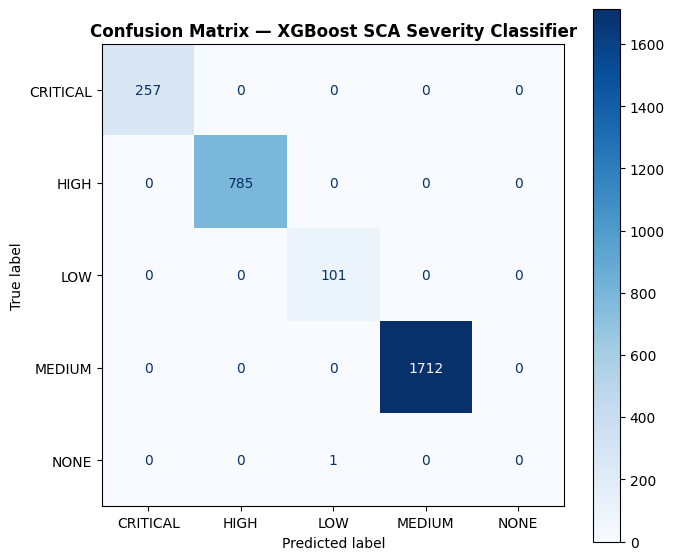

In [11]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=True)
ax.set_title("Confusion Matrix — XGBoost SCA Severity Classifier", fontweight="bold")
plt.tight_layout()
plt.savefig("sca_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

## 🔬 7. SHAP Explanations (Chapter 5.2 — feeds the recommendation engine)

SHAP values quantify each feature's contribution to a given severity prediction,
supporting the Chapter 5.3 recommendation engine's ability to explain *why* a
dependency was flagged, not just *that* it was flagged.

C:\Users\Tejal\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


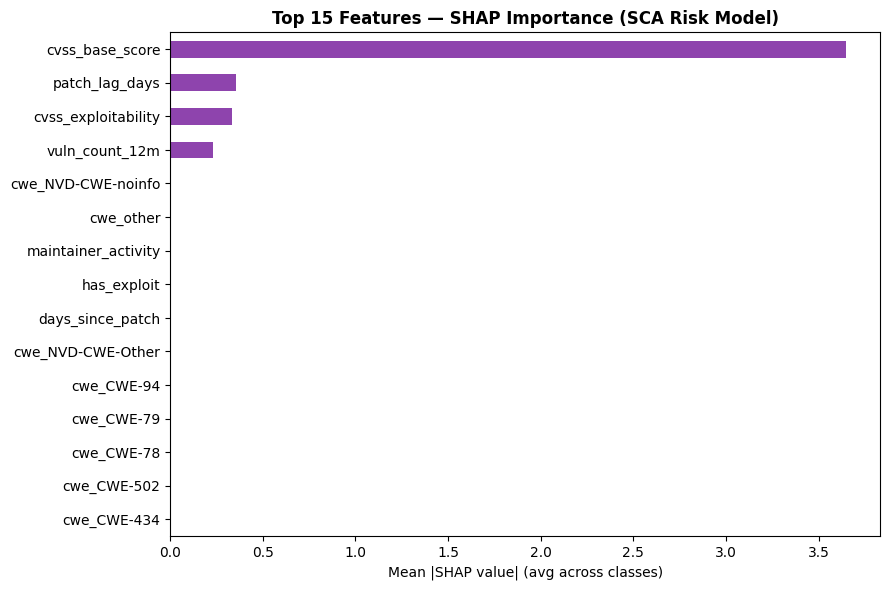

Top features driving severity predictions:
cvss_base_score        3.649189
patch_lag_days         0.355225
cvss_exploitability    0.331533
vuln_count_12m         0.228329
cwe_NVD-CWE-noinfo     0.000970
dtype: float32


In [12]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# shap_values shape: (n_samples, n_features, n_classes) for multi-class in recent SHAP versions
if isinstance(shap_values, list):
    # older SHAP API: one array per class
    mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
else:
    mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))

shap_importance = pd.Series(mean_abs_shap, index=X.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
shap_importance.iloc[::-1].plot(kind="barh", ax=ax, color="#8e44ad")
ax.set_xlabel("Mean |SHAP value| (avg across classes)")
ax.set_title("Top 15 Features — SHAP Importance (SCA Risk Model)", fontweight="bold")
plt.tight_layout()
plt.savefig("sca_shap_importance.png", dpi=120, bbox_inches="tight")
plt.show()

print("Top features driving severity predictions:")
print(shap_importance.head(5))

## 💾 8. Save Model

In [13]:
os.makedirs("models", exist_ok=True)
joblib.dump(model, "models/sca_xgboost.joblib")
joblib.dump(scaler, "models/sca_scaler.joblib")
joblib.dump(le, "models/sca_label_encoder.joblib")
joblib.dump(list(X.columns), "models/sca_feature_columns.joblib")

print("✅ Model saved  → models/sca_xgboost.joblib")
print("✅ Scaler saved → models/sca_scaler.joblib")
print("✅ Labels saved → models/sca_label_encoder.joblib")
print("✅ Feature columns saved → models/sca_feature_columns.joblib")

✅ Model saved  → models/sca_xgboost.joblib
✅ Scaler saved → models/sca_scaler.joblib
✅ Labels saved → models/sca_label_encoder.joblib
✅ Feature columns saved → models/sca_feature_columns.joblib


## 🎯 9. Predict Function (mirrors `predict.ipynb` for the SAST side)

In [14]:
def predict_dependency_risk(feature_row: dict) -> dict:
    """
    feature_row: dict with keys matching NUMERIC_FEATURES + BINARY_FEATURES + cwe_id,
    e.g. {"cvss_base_score": 9.8, "cvss_exploitability": 3.9, "vuln_count_12m": 2,
          "days_since_patch": 45, "patch_lag_days": 30, "dependency_depth": 2,
          "maintainer_activity": 1.5, "has_exploit": 1, "cwe_id": "CWE-89"}
    """
    row = pd.DataFrame([feature_row])
    row_numeric = pd.DataFrame(
        scaler.transform(row[NUMERIC_FEATURES]), columns=NUMERIC_FEATURES
    )
    cwe_val = feature_row.get("cwe_id", "other")
    cwe_col = f"cwe_{cwe_val}" if f"cwe_{cwe_val}" in X.columns else "cwe_other"
    cwe_row = pd.DataFrame(
        [[1 if c == cwe_col else 0 for c in cwe_dummies.columns]], columns=cwe_dummies.columns
    )
    full_row = pd.concat([row_numeric, row[BINARY_FEATURES], cwe_row], axis=1)
    full_row = full_row.reindex(columns=X.columns, fill_value=0)

    proba = model.predict_proba(full_row)[0]
    pred_idx = int(np.argmax(proba))

    return {
        "severity": le.classes_[pred_idx],
        "confidence": round(float(proba[pred_idx]), 4),
        "probabilities": {cls: round(float(p), 4) for cls, p in zip(le.classes_, proba)},
    }


# Example: a Log4Shell-style critical dependency vulnerability
example = {
    "cvss_base_score": 10.0, "cvss_exploitability": 3.9, "vuln_count_12m": 3,
    "days_since_patch": 5, "patch_lag_days": 5, "dependency_depth": 4,
    "maintainer_activity": 2.0, "has_exploit": 1, "cwe_id": "CWE-502",
}
print(predict_dependency_risk(example))

{'severity': 'CRITICAL', 'confidence': 0.9997, 'probabilities': {'CRITICAL': 0.9997, 'HIGH': 0.0002, 'LOW': 0.0, 'MEDIUM': 0.0, 'NONE': 0.0}}


## ✅ 10. Summary

In [15]:
print("SCA Risk Scoring Model Summary")
print("-" * 40)
print(f"Records used     : {len(df):,}")
print(f"Features         : {X.shape[1]}")
print(f"Best params      : {grid_search.best_params_}")
print(f"Test macro-F1    : {macro_f1:.4f}")
print()
print("Ready to plug into the Recommendation Engine (Chapter 5.3) and the")
print("FastAPI backend as POST /sca/analyse ✅")

SCA Risk Scoring Model Summary
----------------------------------------
Records used     : 14,279
Features         : 24
Best params      : {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1.0}
Test macro-F1    : 0.7990

Ready to plug into the Recommendation Engine (Chapter 5.3) and the
FastAPI backend as POST /sca/analyse ✅
